In [1]:
import time
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from utils import draw_latent_z, calc_avg_pk
from models import nuGANGenerator
from collections import OrderedDict
import skimage
if float(skimage.__version__[:4]) < 0.16:
    from skimage.measure import compare_ssim
else:
    from skimage.metrics import structural_similarity
t1 = time.time()

import matplotlib.pylab as pylab
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (12, 8),
         'axes.labelsize':14,
         'axes.titlesize':14,
         'xtick.labelsize':16,
         'ytick.labelsize':16}
pylab.rcParams.update(params)

## Set args and load model

In [3]:
num_maps = 1000

target_maps_path = "./data/test/test_densities.npy"
target_maps = np.load(target_maps_path)
model_path = "./checkpoints/best_model_state_dict.pt"
device = "cuda:0"
mchn = 2
nz = 200
model = nuGANGenerator(nz, mchn).to(device)
state_dict = torch.load(model_path, weights_only=True, map_location=device)
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    new_key = k.replace("module.", "")
    new_state_dict[new_key] = v
model.load_state_dict(new_state_dict)
model.eval()

nu_info = {
    0.0: (0, 0 + num_maps),
    0.1: (1500, 1500 + num_maps),
    0.4: (3000, 4500 + num_maps),
    0.8: (4500, 6000 + num_maps),
    1.2: (6000, 7500 + num_maps),
}

## Get maps and power spectra

In [4]:
synthetic_maps = {}
actual_maps = {}
targ_pk_by_nu = {}
gen_pk_by_nu = {}
tk_by_nu = {}
k = None

for nu,ranges in nu_info.items():
        
        #---Generate maps with nuGAN
        params = torch.Tensor(num_maps*[nu]).to(device)
        z = draw_latent_z(prior="gaussian",
                  sample_shape=(len(params),200),
                  device=device,
                  df=None)
        gen_maps_numass = model(z, params, 2).cpu().detach().squeeze().numpy()        
        k, pksp = calc_avg_pk(gen_maps_numass)
        synthetic_maps[nu] = gen_maps_numass
        gen_pk_by_nu[nu] = pksp

        #---Read target maps
        targ_maps_numass = target_maps[ranges[0]:ranges[1]]
        k, pkst = calc_avg_pk(targ_maps_numass)
        actual_maps[nu] = targ_maps_numass
        targ_pk_by_nu[nu] = pkst

        print(f"Processed neutrino mass {nu}")
        tk_by_nu[nu] = pksp/pkst

Processed neutrino mass 0.0
Processed neutrino mass 0.1
Processed neutrino mass 0.4
Processed neutrino mass 0.8
Processed neutrino mass 1.2


## 1 - Average P(k) and T(k)

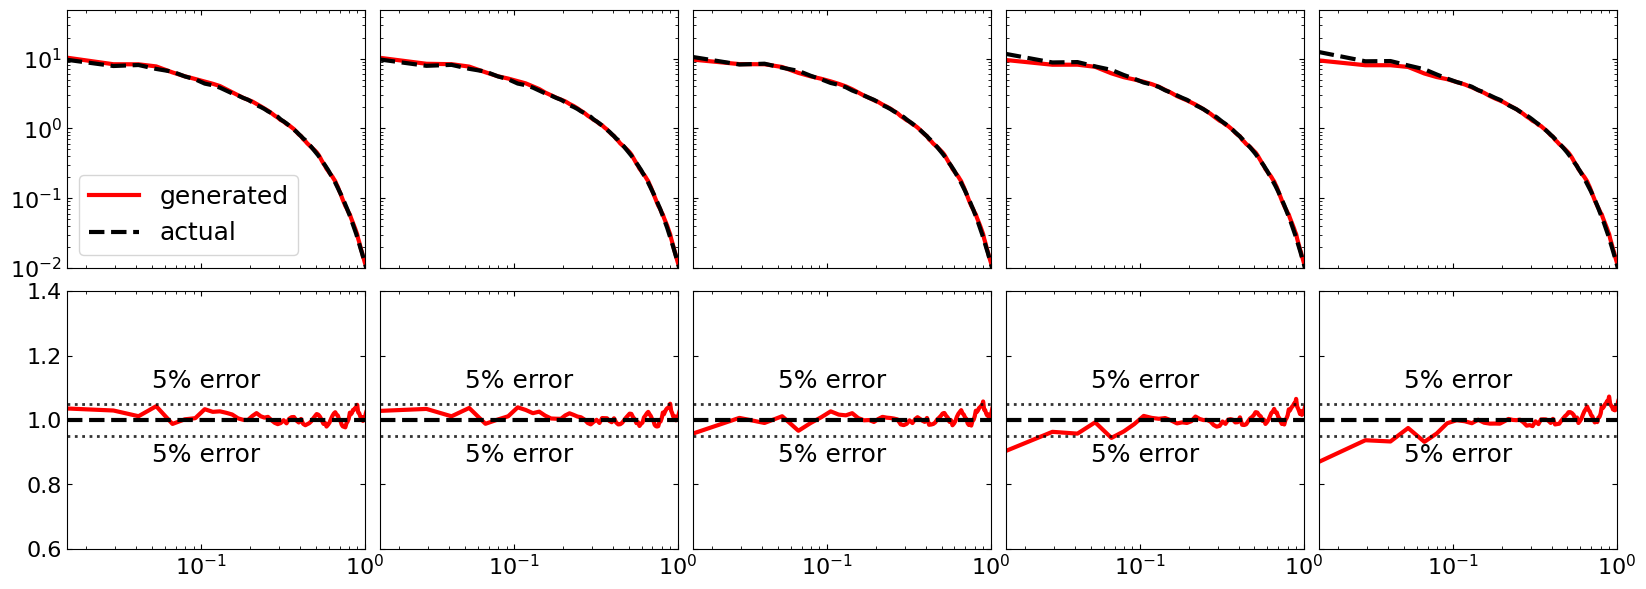

In [6]:
limit_yrange = 'n'
log_yrange = 'n'

#---Top panel (Pk) params
ax_xlims = (k[0], 1)
ax_ylims = (0.01,50)
delta = 0.4

#---Bottom panel (Tk) params
bx_xlims = ax_xlims
bx_ylims = (1.0-delta,1.0+delta)
hlinevals = (1.0-0.05, 1.0+0.05)
text = f"5% error"
text_loc_delta = 0.01

lwd = 3
truelabel = 'actual'
genlabel = 'generated'
legendtextsize = 18
legendpos = "upper right"
annotatedtextsize = 18
labelsize = 14
ticklabelsize = 16
figuresize = (20,7)
text = f"5% error"
text_loc_delta = 0.01
xx,yy1,yy2 = 0.05, 1.1, 0.87

fig, ((ax1,ax2,ax3,ax4,ax5),(bx1,bx2,bx3,bx4,bx5)) = plt.subplots(2,5,figsize=figuresize, sharey="row")
fig.subplots_adjust(
    wspace=0.05,
    hspace=0.09
)
for ax in [ax1,ax2,ax3,ax4,ax5]:
    ax.tick_params(which='both', direction='in', top=True, right=True)

for bx in [bx1,bx2,bx3,bx4,bx5]:
    bx.tick_params(which='both', direction='in', top=True, right=True)


#---Plot P(k)
ax1.loglog(k, gen_pk_by_nu[0.0], c='r', ls='-', lw=3, label=genlabel)
ax1.loglog(k, targ_pk_by_nu[0.0], c='k', ls='--', lw=3, label=truelabel)
ax1.legend(loc="lower left", fontsize=legendtextsize)
ax1.set_xlim(ax_xlims[0], ax_xlims[1])
ax1.set_ylim(ax_ylims[0], ax_ylims[1])
ax1.tick_params(axis='both', labelsize=ticklabelsize)

ax2.loglog(k, gen_pk_by_nu[0.1], c='r', ls='-', lw=3, label=genlabel)
ax2.loglog(k, targ_pk_by_nu[0.1], c='k', ls='--', lw=3, label=truelabel)
ax2.legend(fontsize=legendtextsize)
ax2.set_xlim(ax_xlims[0], ax_xlims[1])
ax2.set_ylim(ax_ylims[0], ax_ylims[1])
ax2.tick_params(axis='both', labelsize=ticklabelsize)

ax3.loglog(k, gen_pk_by_nu[0.4], c='r', ls='-', lw=3, label=genlabel)
ax3.loglog(k, targ_pk_by_nu[0.4], c='k', ls='--', lw=3, label=truelabel)
ax3.legend(fontsize=legendtextsize)
ax3.set_xlim(ax_xlims[0], ax_xlims[1])
ax3.set_ylim(ax_ylims[0], ax_ylims[1])
ax3.tick_params(axis='both', labelsize=ticklabelsize)

ax4.loglog(k, gen_pk_by_nu[0.8], c='r', ls='-', lw=3, label=genlabel)
ax4.loglog(k, targ_pk_by_nu[0.8], c='k', ls='--', lw=3, label=truelabel)
ax4.legend(fontsize=legendtextsize)
ax4.set_xlim(ax_xlims[0], ax_xlims[1])
ax4.set_ylim(ax_ylims[0], ax_ylims[1])
ax4.tick_params(axis='both', labelsize=ticklabelsize)

ax5.loglog(k, gen_pk_by_nu[1.2], c='r', ls='-', lw=3, label=genlabel)
ax5.loglog(k, targ_pk_by_nu[1.2], c='k', ls='--', lw=3, label=truelabel)
ax5.legend(fontsize=legendtextsize)
ax5.set_xlim(ax_xlims[0], ax_xlims[1])
ax5.set_ylim(ax_ylims[0], ax_ylims[1])
ax5.tick_params(axis='both', labelsize=ticklabelsize)


#---Plot T(k)
bx1.plot(k, (tk_by_nu[0.0])**0.5, c='r', ls='-', lw=3, label=genlabel)
bx1.axhline(1, c='k',ls='--', lw=3, label=truelabel)
bx1.axhline(hlinevals[0], c='k', ls=':', lw=2, alpha=0.8)
bx1.axhline(hlinevals[1], c='k', ls=':', lw=2, alpha=0.8)
bx1.text(x=xx, y=yy1, s=text, size=annotatedtextsize)
bx1.text(x=xx, y=yy2, s=text, size=annotatedtextsize)
bx1.legend(loc=legendpos, fontsize=legendtextsize)
bx1.set_xlim(bx_xlims[0], bx_xlims[1])
bx1.set_ylim(bx_ylims[0], bx_ylims[1])
bx1.set_xscale('log')
bx1.tick_params(axis='both', labelsize=ticklabelsize)

bx2.plot(k, (tk_by_nu[0.1])**0.5, c='r', ls='-', lw=3, label=genlabel)
bx2.axhline(1, c='k', ls='--', lw=3, label=truelabel)
bx2.axhline(hlinevals[0], c='k', ls=':', lw=2, alpha=0.8)
bx2.axhline(hlinevals[1], c='k', ls=':', lw=2, alpha=0.8)
bx2.text(x=xx, y=yy1, s=text, size=annotatedtextsize)
bx2.text(x=xx, y=yy2, s=text, size=annotatedtextsize)
bx2.legend(fontsize=legendtextsize)
bx2.set_xlim(bx_xlims[0], bx_xlims[1])
bx2.set_ylim(bx_ylims[0], bx_ylims[1])
bx2.set_xscale('log')
bx2.tick_params(axis='both', labelsize=ticklabelsize)

bx3.plot(k, (tk_by_nu[0.4])**0.5, c='r', ls='-', lw=3, label=genlabel)
bx3.axhline(1, c='k', ls='--', lw=3, label=truelabel)
bx3.axhline(hlinevals[0], c='k', ls=':', lw=2, alpha=0.8)
bx3.axhline(hlinevals[1], c='k', ls=':', lw=2, alpha=0.8)
bx3.text(x=xx, y=yy1, s=text, size=annotatedtextsize)
bx3.text(x=xx, y=yy2, s=text, size=annotatedtextsize)
bx3.legend(fontsize=legendtextsize)
bx3.set_xlim(bx_xlims[0], bx_xlims[1])
bx3.set_ylim(bx_ylims[0], bx_ylims[1])
bx3.set_xscale('log')
bx3.tick_params(axis='both', labelsize=ticklabelsize)

bx4.plot(k, (tk_by_nu[0.8])**0.5, c='r', ls='-', lw=3, label=genlabel)
bx4.axhline(1, c='k', lw=3, ls='--', label=truelabel)
bx4.axhline(hlinevals[0], c='k', ls=':', lw=2, alpha=0.8)
bx4.axhline(hlinevals[1], c='k', ls=':', lw=2, alpha=0.8)
bx4.text(x=xx, y=yy1, s=text, size=annotatedtextsize)
bx4.text(x=xx, y=yy2, s=text, size=annotatedtextsize)
bx4.legend(fontsize=legendtextsize)
bx4.set_xlim(bx_xlims[0], bx_xlims[1])
bx4.set_ylim(bx_ylims[0], bx_ylims[1])
bx4.set_xscale('log')
bx4.tick_params(axis='both', labelsize=ticklabelsize)

bx5.plot(k, (tk_by_nu[1.2])**0.5, c='r', ls='-', lw=3, label=genlabel)
bx5.axhline(1, c='k', ls='--', lw=3, label=truelabel)
bx5.axhline(hlinevals[0], c='k', ls=':', lw=2, alpha=0.8)
bx5.axhline(hlinevals[1], c='k', ls=':', lw=2, alpha=0.8)
bx5.text(x=xx, y=yy1, s=text, size=annotatedtextsize)
bx5.text(x=xx, y=yy2, s=text, size=annotatedtextsize)
bx5.legend(fontsize=legendtextsize)
bx5.set_xlim(bx_xlims[0], bx_xlims[1])
bx5.set_ylim(bx_ylims[0], bx_ylims[1])
bx5.set_xscale('log')
bx5.tick_params(axis='both', labelsize=ticklabelsize)

for ax in [ax2, ax3, ax4, ax5, bx1, bx2, bx3, bx4, bx5]:
    ax.legend_.remove()    
for ax in [ax1, ax2, ax3, ax4, ax5]:
    ax.tick_params(axis='x', labelbottom=False)
fig.savefig(f"./results2/power_spectra.png", dpi=100)
fig.show()

## 2 - Visualizing random maps from nuGAN

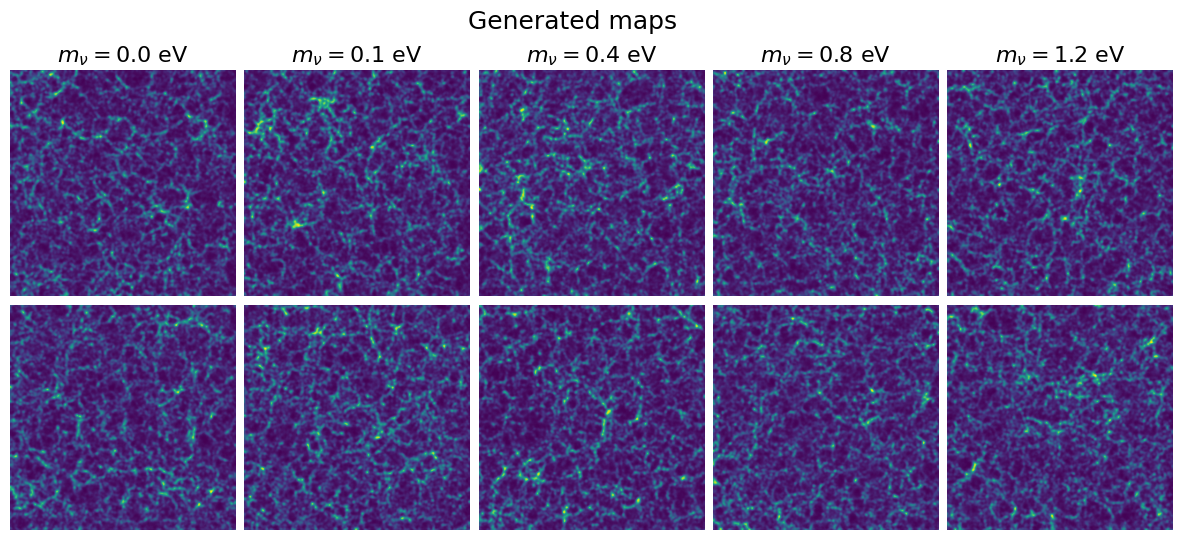

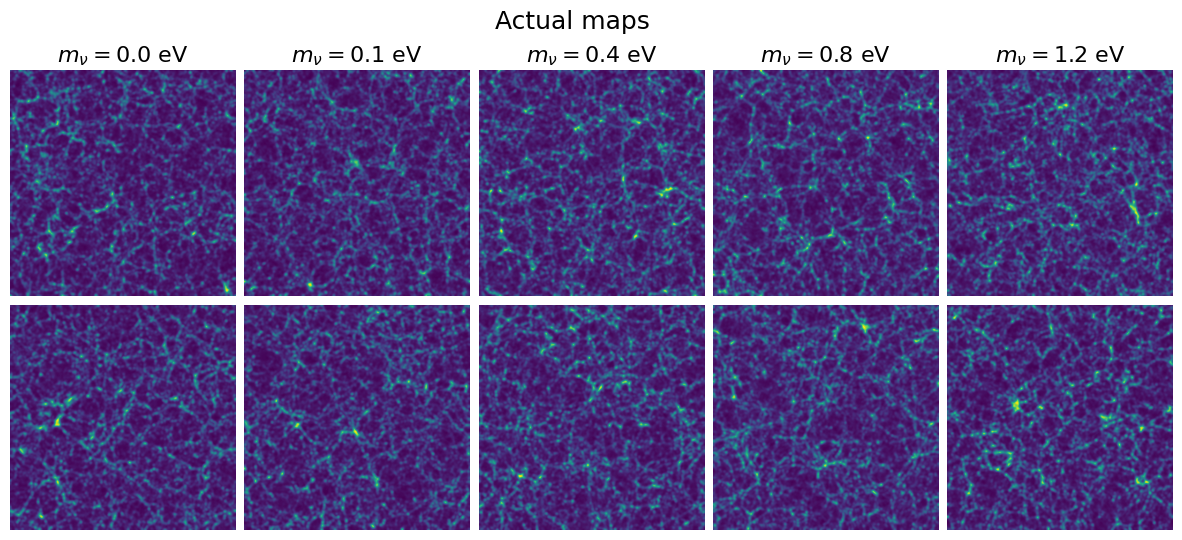

In [7]:
np.random.seed(0)
fig, axes = plt.subplots(2,5,figsize=(15,6), gridspec_kw={'hspace': 0.03, 'wspace': 0.04})

for i, nu in enumerate(nu_info.keys()):
    gen_map1 = synthetic_maps[nu][np.random.choice(synthetic_maps[nu].shape[0])]
    gen_map2 = synthetic_maps[nu][np.random.choice(synthetic_maps[nu].shape[0])]

    axes[0, i].imshow(gen_map1)
    axes[0, i].set_title(f"$m_\\nu = {nu}$ eV", fontsize=16)
    axes[0, i].axis("off")
    axes[1, i].imshow(gen_map2)
    axes[1, i].axis("off")

fig.suptitle('Generated maps', fontsize=18)
fig.show()
fig.savefig("./results2/SAMPLE_MAPS_GENERATED.png", dpi=100)


fig, axes = plt.subplots(2,5,figsize=(15,6), gridspec_kw={'hspace': 0.03, 'wspace': 0.04})
for i, nu in enumerate(nu_info.keys()):
    act_map1 = actual_maps[nu][np.random.choice(actual_maps[nu].shape[0])]
    act_map2 = actual_maps[nu][np.random.choice(actual_maps[nu].shape[0])]

    axes[0, i].imshow(act_map1)
    axes[0, i].set_title(f"$m_\\nu = {nu}$ eV", fontsize=16)
    axes[0, i].axis("off")
    axes[1, i].imshow(act_map2)
    axes[1, i].axis("off")

fig.suptitle('Actual maps', fontsize=18)
fig.show()
fig.savefig("./results2/SAMPLE_MAPS_ACTUAL.png", dpi=100)

## 3 - Comparing actual and synthetic maps for various neutrino masses (fixed latent vector)

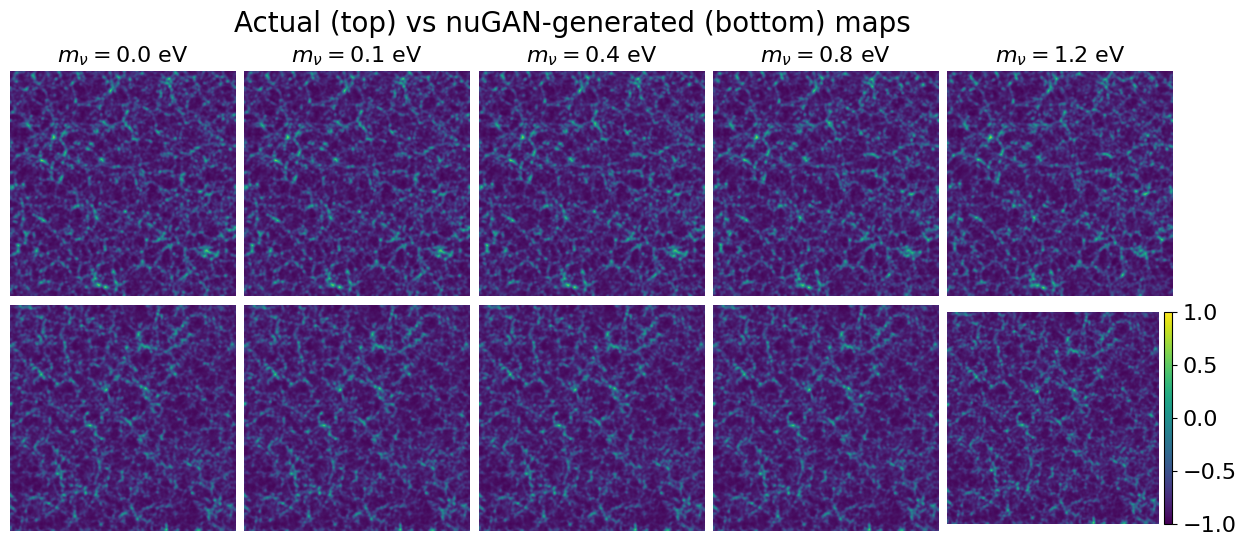

In [ ]:
rs = 65

np.random.seed(rs)
torch.manual_seed(rs)
torch.cuda.manual_seed_all(rs)

z = draw_latent_z(prior="gaussian",
                  sample_shape=(1,200),
                  device=device,
                  df=None)

fig, axes = plt.subplots(2,5,figsize=(15,6), gridspec_kw={'hspace': 0.03, 'wspace': 0.04})
fig.suptitle("Actual (top) vs nuGAN-generated (bottom) maps", fontsize=20)

for i, nu in enumerate(nu_info.keys()):
    act_map = actual_maps[nu][45] #np.random.choice(actual_maps[nu].shape[0])]

    params = torch.Tensor(1*[nu]).to(device)
    gen_map = model(z, params, 2).cpu().detach().squeeze().numpy()         

    axes[0, i].imshow(act_map)
    axes[0, i].set_title(f"$m_\\nu = {nu}$ eV", fontsize=16)
    axes[0, i].axis("off")

    axes[1, i].imshow(gen_map)
    axes[1, i].axis("off")
    
fig.show()

# from mpl_toolkits.axes_grid1 import make_axes_locatable

# for i, nu in enumerate(nu_info.keys()):
#     act_map = actual_maps[nu][45]

#     params = torch.Tensor(1 * [nu]).to(device)
#     gen_map = model(z, params, 2).cpu().detach().squeeze().numpy()

#     im_act = axes[0, i].imshow(act_map, vmin=-1, vmax=1)
#     axes[0, i].set_title(f"$m_\\nu = {nu}$ eV", fontsize=16)
#     axes[0, i].axis("off")

#     im_gen = axes[1, i].imshow(gen_map, vmin=-1, vmax=1)
#     axes[1, i].axis("off")

# # ---- colorbar only for the LAST generated map ----
# divider = make_axes_locatable(axes[1, -1])
# cax = divider.append_axes("right", size="4%", pad=0.05)

# cbar = fig.colorbar(im_gen, cax=cax)
# cbar.set_ticks([-1, -0.5, 0, 0.5, 1])

# fig.show()

#fig.tight_layout()
#fig.savefig("./results2/FIXED_LATENT_VECTOR_MAP_COMPARISON.png", dpi=100)

## 4 - Pixel intensity distribution

In [9]:
def get_single_histogram_fit(data, bins):
    a = np.histogram(data, bins=bins)
    tops = a[0]
    bin_edges = a[1]
    bin_centers = []
    for i in range(len(tops)):
        bin_center = (bin_edges[i] + bin_edges[i+1])/2
        bin_centers.append(bin_center)
    return np.array(bin_centers), np.array(tops)

def get_central_histogram_fit(data, bins, type='median'):
    avg_tops = []
    for i in range(len(data)):
        bc, tops = get_single_histogram_fit(data[i], bins)
        avg_tops.append(tops)
    avg_tops = np.array(avg_tops)
    if type=='mean':
        return bc, np.mean(avg_tops,axis=0)
    elif type=='median':
        return bc, np.median(avg_tops,axis=0)

mybins = np.linspace(-1,1,50)

xx_synth, yy_synth = {}, {}
xx_act, yy_act = {}, {}
frac_error = {}

for nu in nu_info.keys():
    xx_synth[nu], yy_synth[nu] = get_central_histogram_fit(synthetic_maps[nu], bins=mybins)
    xx_act[nu], yy_act[nu] = get_central_histogram_fit(actual_maps[nu], bins=mybins)
    frac_error[nu] = (yy_synth[nu]-yy_act[nu])/yy_act[nu]

/tmp/ipykernel_63707/2833338035.py:31: RuntimeWarning: invalid value encountered in divide
  frac_error[nu] = (yy_synth[nu]-yy_act[nu])/yy_act[nu]


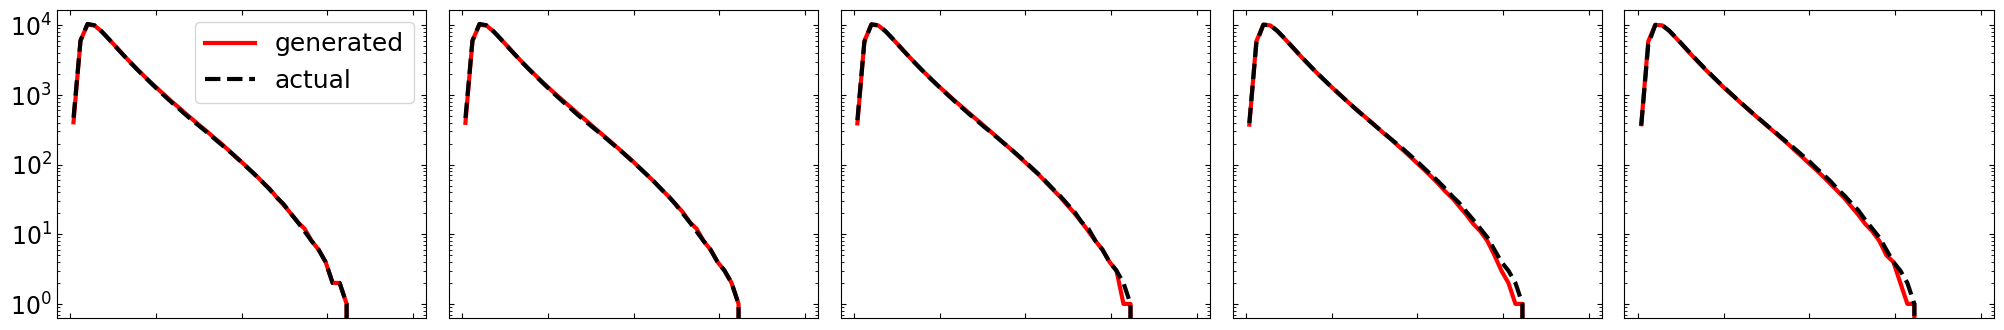

In [10]:
fig, (ax,bx,cx,dx,ex) = plt.subplots(1,5, figsize=(25,4), sharey=True)
fig.subplots_adjust(
    wspace=0.06,
    hspace=0.09
)
for xx in [ax,bx,cx,dx,ex]:
    xx.tick_params(which='both', direction='in', top=True, right=True)

for nu, sp in zip(nu_info.keys(),(ax,bx,cx,dx,ex)):
    sp.plot(xx_synth[nu], yy_synth[nu], marker=None, c= 'r', label='generated', lw=3)
    sp.plot(xx_act[nu], yy_act[nu], marker=None, c= 'k', label='actual', lw=3, ls='--')
    sp.set_xticks([-1,-0.5,0,0.5,1.0])
    sp.legend(fontsize=legendtextsize)
    sp.set_yscale('log')
    sp.tick_params(axis='both', labelsize=ticklabelsize+1)

for xx in [bx,cx,dx,ex]:
    xx.legend_.remove()
for xx in [ax,bx,cx,dx,ex]:
    xx.tick_params(axis='x', labelbottom=False)    

fig.savefig("./results2/PIXEL_INTENSITY_DISTRIBUTION.png", dpi=100)
plt.show()

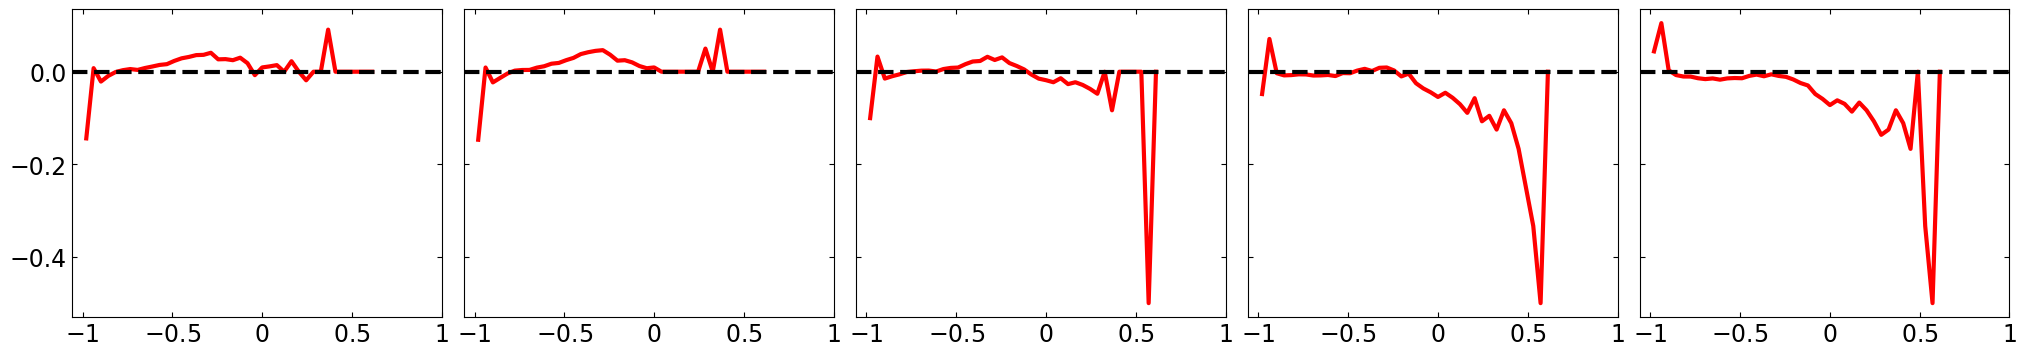

In [11]:
fig, (ax,bx,cx,dx,ex) = plt.subplots(1,5, figsize=(25,4), sharey=True)
fig.subplots_adjust(
    wspace=0.06,
    hspace=0.10
)
for xx in [ax,bx,cx,dx,ex]:
    xx.tick_params(which='both', direction='in', top=True, right=True)

for nu, sp in zip(nu_info.keys(),(ax,bx,cx,dx,ex)):
    sp.plot(xx_synth[nu], frac_error[nu], marker=None, c= 'r', label='synthetic', lw=3)
    sp.axhline(0, marker=None, c='k', ls='--', label='actual', lw=3)
    #sp.set_xticks([-1,-0.5,0,0.5,1.0])
    sp.set_xticks([-1, -0.5, 0, 0.5, 1])
    sp.set_xticklabels(
        [r"$-1$", r"$-0.5$", r"$0$", r"$0.5$", r"$1$"],
        fontsize=ticklabelsize
    )
    sp.tick_params(axis='both', labelsize=ticklabelsize+1)
fig.savefig("./results2/PIXEL_INTENSITY_DISTRIBUTION_ERROR.png", dpi=100)
plt.show()

## 5 - Pixel peaks distribution comparison

In [12]:
import scipy.ndimage
def peak_count(X, neighborhood_size=5, threshold=0.5):
    """
    Peak count for a 2D or a 3D square image
    :param X: numpy array shape [n,n] or [n,n,n]
    :param neighborhood_size: size of the local neighborhood that should be filtered
    :param threshold: minimum distance betweent the minimum and the maximum to be considered a local maximum. Helps remove noise peaks (0.5 since the number of particle is supposed to be an integer)
    :return: vector of peaks found in the array (int)
    """
    size = len(X.shape)
    if len(X.shape) == 1:
        pass
    elif size==2:
        assert(X.shape[0]==X.shape[1])
    elif size==3:
        assert(X.shape[0]==X.shape[1]==X.shape[2])
    else:
        raise Exception(" [!] Too many dimensions")

    data_max = scipy.ndimage.maximum_filter(X, neighborhood_size, mode="reflect")
    #maxima = (X == data_max)
    maxima = np.isclose(X, data_max, rtol=1e-9, atol=1e-9)
    if threshold != 0:
        data_min = scipy.ndimage.minimum_filter(X, neighborhood_size, mode="reflect")
        diff = ((data_max - data_min) >= threshold)
        #maxima[diff == 0] = 0
        maxima = maxima & diff
    
    return np.extract(maxima, X)

def get_pixel_peak_histogram(maps_dict, nbins=30, avg_type="median", neighborhood_size=5, threshold=0.25):
    """
    Median pixel histogram for 2D cosmic web images
    :param image_dict: a dictionary {0.0:[img1,img2,...], 0.4:[img1,img2,...], ...]} containing 2D images
    :param nbins: Number of bins desired in the histogram
    :param avg_type: Whether mean is desired or median
    :return: tuple->(dict,ndarray), where dict is {0.0:counts, 0.1:counts, ...} and
                                          ndarray is the array of center of bin edges
    """
    
    #----Get binning for all maps for each neutrino mass
    all_counts = {0.0:[],0.1:[],0.4:[],0.8:[],1.2:[]}
    for sample in range(num_maps):
        for nu in nu_info.keys():    
            peak_counts  = peak_count(maps_dict[nu][sample],
                                      neighborhood_size=neighborhood_size,
                                      threshold=threshold)
            counts, bins = np.histogram(peak_counts, bins=nbins, range=(-1,1))
            all_counts[nu].append(counts)
            if sample==0:
                all_bins = bins

    #----Center the bins
    bincenters = []
    for i in range(len(all_bins)-1):
        bin_center = (all_bins[i]+all_bins[i+1])/2
        bincenters.append(bin_center)
    bincenters = np.array(bincenters)

    #----Get median counts for each neutrino mass
    central_counts = {0.0:0, 0.1:0, 0.4:0, 0.8:0, 1.2:0}
    for nu in maps_dict.keys():
        if avg_type=="median":
            central_hist = np.median(np.array(all_counts[nu]), axis=0)
        elif avg_type=="mean":
            central_hist = np.mean(np.array(all_counts[nu]), axis=0)
        central_counts[nu] = central_hist
        
    return all_counts, central_counts, bincenters

print("Processing synthetic samples")
all_counts_synth, avg_counts_synth, bin_centers_synth = get_pixel_peak_histogram(synthetic_maps,
                                                                                 nbins=50,
                                                                                 avg_type="median",
                                                                                 neighborhood_size=5,
                                                                                 threshold=0.25)

print("Processing actual samples")
all_counts_act, avg_counts_act, bin_centers_act = get_pixel_peak_histogram(actual_maps,
                                                                                 nbins=50,
                                                                                 avg_type="median",
                                                                                 neighborhood_size=5,
                                                                                 threshold=0.25)

Processing synthetic samples
Processing actual samples


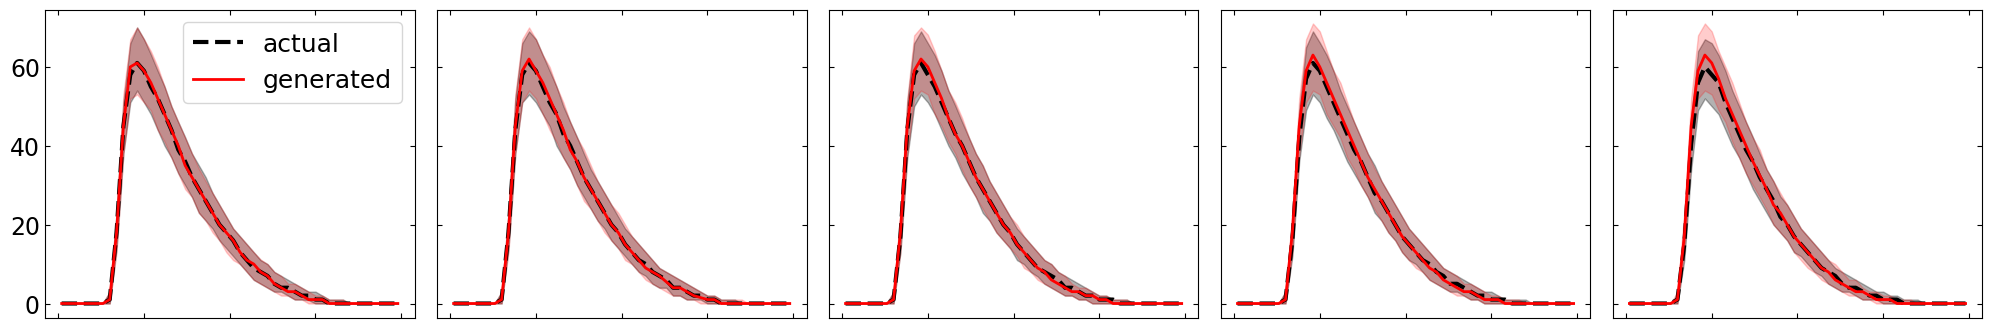

In [13]:
fig, (ax,bx,cx,dx,ex) = plt.subplots(1,5, figsize=(25,4), sharey=True)
fig.subplots_adjust(
    wspace=0.06,
    hspace=0.10
)
for xx in [ax,bx,cx,dx,ex]:
    xx.tick_params(which='both', direction='in', top=True, right=True)

for nu, sp in zip(list(nu_info.keys()),(ax,bx,cx,dx,ex)):
        
    q16r = np.quantile(np.array(all_counts_act[nu]), q=0.16, axis=0)
    q84r = np.quantile(np.array(all_counts_act[nu]), q=0.84, axis=0)
    sp.plot(bin_centers_act, avg_counts_act[nu], c='k', ls='--', lw=3, label='actual')
    sp.fill_between(bin_centers_act, q16r, q84r, alpha=0.3, color='k')
    
    q16f = np.quantile(np.array(all_counts_synth[nu]), q=0.16, axis=0)
    q84f = np.quantile(np.array(all_counts_synth[nu]), q=0.84, axis=0)
    sp.plot(bin_centers_synth, avg_counts_synth[nu], c='r', lw=2, label='generated')
    sp.fill_between(bin_centers_synth, q16f, q84f, alpha=0.2, color='r')

    sp.set_xticks([-1,-0.5,0,0.5,1.0])
    sp.legend(fontsize=legendtextsize)
    sp.tick_params(axis='both', labelsize=ticklabelsize+1)
    
for xx in [bx,cx,dx,ex]:
    xx.legend_.remove()
for xx in [ax,bx,cx,dx,ex]:
    xx.tick_params(axis='x', labelbottom=False) 
fig.savefig("./results2/PIXEL_PEAKS_DISTRIBUTION.png", dpi=100)
plt.show()

/tmp/ipykernel_63707/3731212786.py:31: RuntimeWarning: invalid value encountered in divide
  res = (avg_counts_synth[nu] - avg_counts_act[nu])/avg_counts_act[nu]


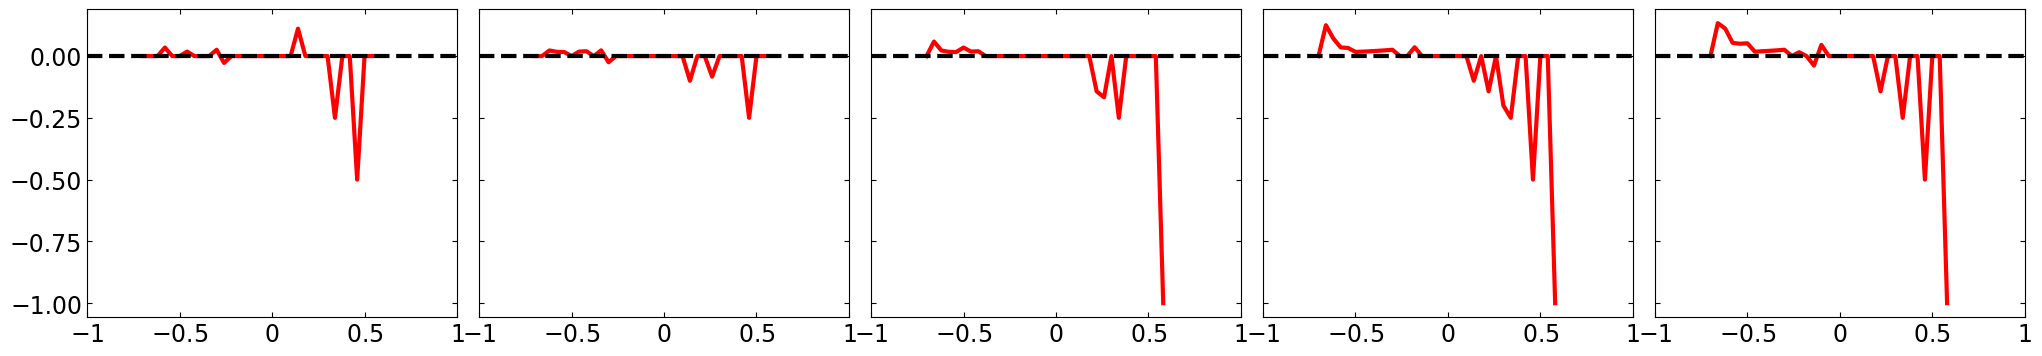

In [14]:
fig, (ax,bx,cx,dx,ex) = plt.subplots(1,5, figsize=(25,4), sharey=True)
fig.subplots_adjust(
    wspace=0.06,
    hspace=0.10
)
for xx in [ax,bx,cx,dx,ex]:
    xx.tick_params(which='both', direction='in', top=True, right=True)

option = 3

for nu, sp in zip(nu_info.keys(),(ax,bx,cx,dx,ex)):

    if option==1:
        real = avg_counts_act[nu]
        synth = avg_counts_synth[nu]
        mask = real > 0
        res = np.full_like(real, np.nan, dtype=float)
        res[mask] = (synth[mask] - real[mask]) / real[mask]
        #print(res)

    elif option==2:
        res = np.divide(
                    avg_counts_synth[nu] - avg_counts_act[nu],
                    avg_counts_act[nu],
                    out=np.zeros_like(avg_counts_act[nu], dtype=float),
                    where=avg_counts_act[nu] > 0
                )
        #print(res)
    
    elif option==3:
        res = (avg_counts_synth[nu] - avg_counts_act[nu])/avg_counts_act[nu]


    sp.plot(bin_centers_act, res, c='r', lw=3, label='generated')
    sp.axhline(0.0, c='k', ls='--', lw=3, label='actual')

    #sp.legend(fontsize=16)
    #sp.set_ylim(-0.5,0.5)

    sp.set_xticks([-1, -0.5, 0, 0.5, 1])
    sp.set_xticklabels(
        [r"$-1$", r"$-0.5$", r"$0$", r"$0.5$", r"$1$"],
        fontsize=ticklabelsize
    )
    sp.tick_params(axis='both', labelsize=ticklabelsize+1)

fig.savefig("./results2/PIXEL_PEAKS_DISTRIBUTION_ERROR.png", dpi=100)
plt.show()

## 5 - MS-SSIM

In [15]:
rseed = 97
random.seed(rseed)
np.random.seed(rseed)
NN = 5000
digs = 3

def ssim(X, Y, ncomp=1000):
    ssim_vals = []
    for _ in range(ncomp):
        i, j = np.random.randint(0, len(X)), np.random.randint(0, len(Y))
        if X is Y:
            while i==j:
                j = np.random.randint(0, len(Y))
        ssim_vals.append(structural_similarity(X[i], Y[j], data_range=2)) #Y[j].max() - Y[j].min()))
        #ssim_vals.append(structural_similarity(synths[i], actuals[j], data_range=2))
    return np.array(ssim_vals)

def get_res(ssim_a, ssim_b):
    return 2.0*(np.mean(ssim_a) - np.mean(ssim_b)) / (np.std(ssim_a)+np.std(ssim_b))

for nu in nu_info.keys():
    ssims_cross = ssim(synthetic_maps[nu], actual_maps[nu], ncomp=NN)
    ssims_synths = ssim(synthetic_maps[nu], synthetic_maps[nu], ncomp=NN)
    ssims_actuals = ssim(actual_maps[nu], actual_maps[nu], ncomp=NN)
    print(f"Mean SSIM for nu={nu} eV - (Actual:{round(np.mean(ssims_actuals),digs)}), (Synthetic:{round(np.mean(ssims_synths),digs)}), (Cross:{round(np.mean(ssims_cross),digs)})")

    print(f"MS-SSIM for nu={nu} eV:", get_res(ssims_synths, ssims_actuals))

Mean SSIM for nu=0.0 eV - (Actual:0.137), (Synthetic:0.135), (Cross:0.13)
MS-SSIM for nu=0.0 eV: -0.039978453816352025
Mean SSIM for nu=0.1 eV - (Actual:0.136), (Synthetic:0.136), (Cross:0.13)
MS-SSIM for nu=0.1 eV: -0.003519403310617075
Mean SSIM for nu=0.4 eV - (Actual:0.137), (Synthetic:0.135), (Cross:0.131)
MS-SSIM for nu=0.4 eV: -0.0336527478534609
Mean SSIM for nu=0.8 eV - (Actual:0.137), (Synthetic:0.138), (Cross:0.132)
MS-SSIM for nu=0.8 eV: 0.02128645862312759
Mean SSIM for nu=1.2 eV - (Actual:0.138), (Synthetic:0.141), (Cross:0.133)
MS-SSIM for nu=1.2 eV: 0.08569226854801655
